In [27]:
# Street view
!git clone https://github.com/KI4Kids/bike.git

Cloning into 'bike'...
remote: Enumerating objects: 12, done.
remote: Counting objects: 100% (12/12), done.
remote: Compressing objects: 100% (10/10), done.
remote: Total 12 (delta 0), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (12/12), 14.27 MiB | 5.42 MiB/s, done.


PRO TIP 💡 Replace 'model=yolov5s.pt' with new 'model=yolov5su.pt'.
YOLOv5 'u' models are trained with https://github.com/ultralytics/ultralytics and feature improved performance vs standard YOLOv5 models trained with https://github.com/ultralytics/yolov5.


0: 320x640 13 persons, 5 bicycles, 6 cars, 1 backpack, 253.6ms
Speed: 2.6ms preprocess, 253.6ms inference, 4.8ms postprocess per image at shape (1, 3, 320, 640)


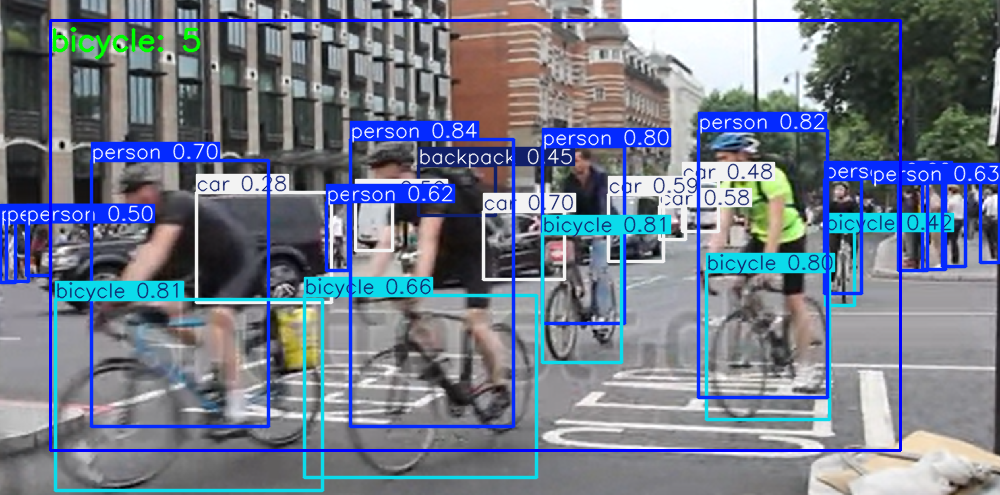

Programm Ende


In [43]:
# Installiere notwendige Bibliotheken in Colab
!pip install ultralytics opencv-python

import cv2
from ultralytics import YOLO
from google.colab.patches import cv2_imshow
import numpy as np

# Pfad zu deinem Video/Bild
video_path = "/content/bike/bike/bike.png"

# Öffne das Video/Bild
cap = cv2.VideoCapture(video_path)

# Überprüfe, ob das Video/Bild geöffnet wurde
if not cap.isOpened():
    print("Fehler beim Öffnen des Videos/Bildes!")
    exit()

# Auflösung und FPS festlegen
w, h, fps = (int(cap.get(x)) for x in (cv2.CAP_PROP_FRAME_WIDTH, cv2.CAP_PROP_FRAME_HEIGHT, cv2.CAP_PROP_FPS))

# Funktion zur Änderung der Auflösung
def change_res(width, height):
    cap.set(3, width)
    cap.set(4, height)

change_res(1200, 720)

# Lade das YOLO-Modell von Ultralytics
model = YOLO("yolov5s.pt")  # Modell für schnelle Objekterkennung (z.B. YOLOv5s)

# Region, in der Objekte gezählt werden (optional)
#region_points = [(50, 20), (450, 20), (450, 450), (50, 450)]
region_points = [(50, 20), (900, 20), (900, 450), (50, 450)]

while True:
    success, frame = cap.read()

    # Wenn das Frame nicht erfolgreich geladen wurde, breche die Schleife ab
    if not success:
        print("Programm Ende")
        break

    # Verarbeite das Frame mit YOLO
    results = model(frame)

    # Zähler im COCO-Dataset
    person_count = 0

    # Extrahiere die Klasse und Zähle Personen (Klasse im COCO-Dataset)
    for r in results:
        # Access the boxes attribute which contains bounding box information
        for box in r.boxes:
            cls = int(box.cls[0])  # class id
            if cls == 1:  # Klasse in COCO 1=bicycle
                person_count += 1

    # Zeige das Ergebnis im Video an
    frame_with_boxes = results[0].plot()  # Rendering of bounding boxes

    # Optional: Region im Video anzeigen
    cv2.polylines(frame_with_boxes, [np.array(region_points)], isClosed=True, color=(255, 0, 0), thickness=2)

    # Anzeige des Zählwerts im Video (mit OpenCV Text-Overlay)
    cv2.putText(frame_with_boxes, f'bicycle: {person_count}', (50, 50), cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 2, cv2.LINE_AA)

    # Zeige das verarbeitete Bild im Video-Stream
    cv2_imshow(frame_with_boxes)

    # Warte kurz, um die FPS des Streams beizubehalten
  #  cv2.waitKey(1)  # Warte 1ms, um den Stream fortzusetzen

# Ressourcen freigeben
cap.release()
#cv2.destroyAllWindows()
